## Resumen
Este notebook realiza EDA del gap entre la media reportada por PIP y la media implicita en los 1000 bins: mide magnitud, direccion y patrones por region, tipo de bienestar y survey, e identifica paises/anios problematicos.

# Exercise - EDA: PIP mean vs 1000-bin mean

Objective: understand, quantify and explain the differences between PIP average income (`mean`) and the average constucted using a 1000 bins distribution (`mean_1kbins`).

The plan is the following:

1. Load and review data set
2. Define measures of absolute and relative difference
3. Understand distribution of problem
4. Identify problematic countries/years
5. Look into region, country, welfare type, survey and time trends 
6. Double click

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None
    plt.style.use("default")

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
ROOT = Path(r"C:\Users\wb661551\OneDrive - WBG\Desktop\Internship\Bottom Censoring")
INPUT = ROOT / "01-input"
OUT = ROOT / "work"

pip_bins_path = INPUT / "pip_1kbins.dta"
pip_1000_bins_path = INPUT / "GlobalDist1000bins_1990_2026_20260324_2021_01_02_PROD.dta"
MWI_1997_path = INPUT / "country" / "MWI_1997.dta"
pip_bins_path

WindowsPath('C:/Users/wb661551/OneDrive - WBG/Desktop/Internship/Bottom Censoring/01-input/pip_1kbins.dta')

## 1. Load dataset and review structure

`pip_1kbins.dta` already merges PIP variables and the average calculated from a 1000 bins distribution.

In [3]:
df = pd.read_stata(pip_bins_path)

df.shape, df.columns.tolist()

((2238, 46),
 ['country_code',
  'country_name',
  'region_code',
  'region_name',
  'reporting_level',
  'year',
  'welfare_time',
  'welfare_type',
  'poverty_line',
  'headcount',
  'poverty_gap',
  'poverty_severity',
  'watts',
  'gini',
  'median',
  'mld',
  'polarization',
  'population',
  'decile1',
  'decile2',
  'decile3',
  'decile4',
  'decile5',
  'decile6',
  'decile7',
  'decile8',
  'decile9',
  'decile10',
  'cpi',
  'ppp',
  'gdp',
  'hfce',
  'survey_comparability',
  'survey_acronym',
  'survey_time',
  'is_interpolated',
  'distribution_type',
  'survey_coverage',
  'comparable_spell',
  'spl',
  'spr',
  'pg',
  'mean',
  'mean_1kbins',
  'headcount_1kbins',
  'pop'])

In [4]:
df

,country_code,country_name,region_code,region_name,reporting_level,year,welfare_time,welfare_type,poverty_line,headcount,poverty_gap,poverty_severity,watts,gini,median,mld,polarization,population,decile1,decile2,decile3,decile4,decile5,decile6,decile7,decile8,decile9,decile10,cpi,ppp,gdp,hfce,survey_comparability,survey_acronym,survey_time,is_interpolated,distribution_type,survey_coverage,comparable_spell,spl,spr,pg,mean,mean_1kbins,headcount_1kbins,pop
0,AGO,Angola,SSF,Sub-Saharan Africa,national,"2,000.0000","2,000.2100",consumption,3,0.2695,0.1192,0.0706,0.1974,0.5195,5.3004,0.5095,0.4643,"16,310,860.1900",0.0099,0.0220,0.0334,0.0451,0.0565,0.0705,0.0882,0.1134,0.1594,0.4017,0.0066,203.6887,"2,172.4633",NaN,0,HBS,2000-2001,FALSE,micro,national,2000,3.9500,0.3715,9.6092,8.3708,8.3573,0.2700,16.1949
1,AGO,Angola,SSF,Sub-Saharan Africa,national,"2,008.0000","2,008.5000",consumption,3,0.2208,0.0667,0.0290,0.0905,0.4272,5.3342,0.3116,0.3914,"21,996,714.0000",0.0207,0.0336,0.0432,0.0530,0.0654,0.0792,0.0965,0.1230,0.1623,0.3230,0.1406,203.6887,"3,559.1952","1,748.4284",1,IBEP-MICS,2008-2009,FALSE,micro,national,2008,3.9670,0.3534,6.8388,7.7159,7.7091,0.2160,21.5787
2,AGO,Angola,SSF,Sub-Saharan Africa,national,"2,018.0000","2,018.1700",consumption,3,0.3929,0.1630,0.0893,0.2520,0.5126,3.8795,0.4764,0.4710,"31,480,496.0900",0.0133,0.0243,0.0333,0.0434,0.0558,0.0698,0.0887,0.1157,0.1594,0.3962,0.5716,203.6887,"3,196.7901","2,261.4557",2,IDREA,2018-2019,FALSE,micro,national,2018,3.2400,0.4216,10.9642,6.3460,6.3329,0.3850,31.2972
3,ALB,Albania,ECS,Europe & Central Asia,national,"1,996.0000","1,996.0000",consumption,3,0.0297,0.0044,0.0012,0.0052,0.2701,7.4193,0.1191,0.2413,"3,168,033.0000",0.0388,0.0528,0.0637,0.0752,0.0835,0.0925,0.1078,0.1261,0.1525,0.2071,0.3725,50.7723,"1,683.7697","1,522.8719",0,EWS,1996,FALSE,micro,national,1996,5.0100,0.2039,4.2094,8.4420,8.4331,0.0290,3.1680
4,ALB,Albania,ECS,Europe & Central Asia,national,"2,002.0000","2,002.0000",consumption,3,0.0419,0.0072,0.0021,0.0088,0.3174,7.1172,0.1648,0.2690,"3,051,010.0000",0.0352,0.0485,0.0585,0.0674,0.0764,0.0884,0.1023,0.1199,0.1500,0.2534,0.6540,50.7723,"2,297.1085","1,572.2955",1,LSMS,2002,FALSE,micro,national,2002 - 2012,4.8590,0.2244,4.4293,8.6283,8.6203,0.0420,3.0510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2233,ZMB,Zambia,SSF,Sub-Saharan Africa,national,"2,015.0000","2,015.0000",consumption,3,0.6789,0.3799,0.2533,0.6774,0.5584,1.8183,0.5643,0.5839,"16,399,089.0000",0.0116,0.0198,0.0274,0.0358,0.0474,0.0617,0.0822,0.1116,0.1682,0.4342,0.4804,6.1896,"1,295.8779",603.8121,4,LCMS-VII,2015,FALSE,micro,national,2010 - 2022,3.0000,0.6789,22.8941,3.3653,3.3614,0.6790,16.3991
2234,ZMB,Zambia,SSF,Sub-Saharan Africa,national,"2,022.0000","2,022.0000",consumption,3,0.7166,0.3976,0.2613,0.6957,0.5148,1.6792,0.4657,0.5356,"20,152,938.0000",0.0147,0.0238,0.0321,0.0412,0.0522,0.0670,0.0871,0.1178,0.1733,0.3909,1.1099,6.1896,"1,298.8480",NaN,4,LCMS-VIII,2022,FALSE,imputed,national,2010 - 2022,3.0000,0.7166,22.8530,2.8581,2.8577,0.7170,20.1529
2235,ZWE,Zimbabwe,SSF,Sub-Saharan Africa,national,"2,011.0000","2,011.0000",consumption,3,0.3572,0.1132,0.0470,0.1487,0.4315,3.9314,0.3071,0.3884,"13,595,424.0000",0.0248,0.0335,0.0426,0.0524,0.0635,0.0766,0.0932,0.1169,0.1583,0.3383,0.7134,0.6442,"1,184.9342",885.3590,0,ICES,2011,FALSE,group,national,2011 - 2019,3.2660,0.4012,8.5098,5.6504,5.6501,0.3570,13.5954
2236,ZWE,Zimbabwe,SSF,Sub-Saharan Africa,national,"2,017.0000","2,017.0000",consumption,3,0.4466,0.1475,0.0630,0.1964,0.4434,3.3001,0.3228,0.4167,"14,812,482.0000",0.0254,0.0343,0.0416,0.0497,0.0595,0.0723,0.0897,0.1166,0.1630,0.3480,0.6558,0.6442,"1,422.9195","1,167.2535",0,PICES,2017,FALSE,micro,national,2011 - 2019,3.0000,0.4466,9.6338,5.0620,5.0541,0.4470,14.8125


In [5]:
key_cols = [
    "country_code", "country_name", "region_code", "region_name", "year",
    "welfare_type", "survey_acronym", "reporting_level", "mean", "mean_1kbins",
    "gini", "median", "decile10", "pop"
]

df[key_cols].head()

,country_code,country_name,region_code,region_name,year,welfare_type,survey_acronym,reporting_level,mean,mean_1kbins,gini,median,decile10,pop
0,AGO,Angola,SSF,Sub-Saharan Africa,"2,000.0000",consumption,HBS,national,8.3708,8.3573,0.5195,5.3004,0.4017,16.1949
1,AGO,Angola,SSF,Sub-Saharan Africa,"2,008.0000",consumption,IBEP-MICS,national,7.7159,7.7091,0.4272,5.3342,0.3230,21.5787
2,AGO,Angola,SSF,Sub-Saharan Africa,"2,018.0000",consumption,IDREA,national,6.3460,6.3329,0.5126,3.8795,0.3962,31.2972
3,ALB,Albania,ECS,Europe & Central Asia,"1,996.0000",consumption,EWS,national,8.4420,8.4331,0.2701,7.4193,0.2071,3.1680
4,ALB,Albania,ECS,Europe & Central Asia,"2,002.0000",consumption,LSMS,national,8.6283,8.6203,0.3174,7.1172,0.2534,3.0510


In [6]:
df[["mean", "mean_1kbins"]].mean()

mean          27.6043
mean_1kbins   27.5463
dtype: float64

In [7]:
df.groupby("country_name")[["mean", "mean_1kbins"]].mean()


,mean,mean_1kbins
country_name,,
Albania,11.8041,11.7989
Algeria,9.2298,9.2297
Angola,7.4775,7.4664
Argentina,25.7082,25.6930
Armenia,8.4031,8.3975
...,...,...
Viet Nam,9.8905,9.8828
West Bank and Gaza,14.3552,14.3479
"Yemen, Rep.",5.9510,5.9502


## 2. Define gap

Three different measures:

- `diff_mean`: difference of means, `mean - mean_1kbins`.
- `abs_diff_mean`: absolute difference of means 
- `abs_diff_mean_pct`: relative difference with respect to PIP mean

If `diff_mean > 0`, PIP mean is greater than 1000 bin average.  

In [8]:
eda = df.copy()
eda["year"] = eda["year"].astype(int)
eda["diff_mean"] = eda["mean"] - eda["mean_1kbins"]
eda["abs_diff_mean"] = eda["diff_mean"].abs()
eda["abs_diff_mean_pct"] = eda["abs_diff_mean"] / eda["mean"]
eda["diff_mean_pct_signed"] = eda["diff_mean"] / eda["mean"]

eda[["mean", "mean_1kbins", "diff_mean", "abs_diff_mean", "abs_diff_mean_pct"]].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.995,0.999,0.9999]
)

,mean,mean_1kbins,diff_mean,abs_diff_mean,abs_diff_mean_pct
count,"2,238.0000","2,238.0000","2,238.0000","2,238.0000","2,238.0000"
mean,27.6043,27.5463,0.0580,0.0580,0.0015
std,23.3953,23.3224,0.1320,0.1320,0.0039
min,1.1047,1.1041,-0.0089,0.0000,0.0000
50%,17.7149,17.6988,0.0099,0.0099,0.0006
75%,43.9068,43.8810,0.0388,0.0388,0.0015
90%,65.1422,65.1049,0.1835,0.1835,0.0041
95%,74.2388,73.9630,0.2970,0.2970,0.0061
99%,86.8052,86.7290,0.6619,0.6619,0.0103
99.5%,89.8678,89.3954,0.7374,0.7374,0.0118


## 3. How big is the problem? 

First, I look at the complete distribution of differences, separating between absolute difference and percentage difference.

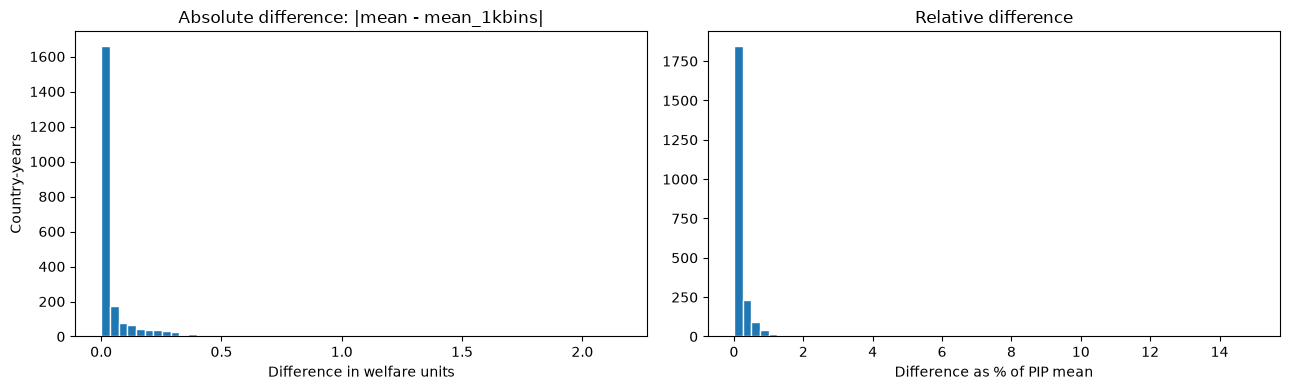

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(eda["abs_diff_mean"], bins=60, edgecolor="white")
axes[0].set_title("Absolute difference: |mean - mean_1kbins|")
axes[0].set_xlabel("Difference in welfare units")
axes[0].set_ylabel("Country-years")

axes[1].hist(100 * eda["abs_diff_mean_pct"], bins=60, edgecolor="white")
axes[1].set_title("Relative difference")
axes[1].set_xlabel("Difference as % of PIP mean")

plt.tight_layout()

In [10]:
# Counts how many country-years have a relative difference above certain thresholds
thresholds = pd.DataFrame({
    "threshold_pct": [0.1, 0.25, 0.5, 1, 2, 5, 10],
})
thresholds["n_country_years"] = thresholds["threshold_pct"].apply(
    lambda x: (100 * eda["abs_diff_mean_pct"] >= x).sum()
)
thresholds["share_country_years"] = thresholds["n_country_years"] / len(eda)
thresholds

,threshold_pct,n_country_years,share_country_years
0,0.1000,714,0.3190
1,0.2500,391,0.1747
2,0.5000,159,0.0710
3,1.0000,25,0.0112
4,2.0000,3,0.0013
5,5.0000,1,0.0004
6,10.0000,1,0.0004


In [11]:
# Caso que me paso Yuki pero que pienso no es problematico 
eda[(eda["country_code"] == "CHE") & (eda["year"] == 2020)] 
eda[(eda["country_code"] == "MWI") & (eda["year"] == 2019)]


,country_code,country_name,region_code,region_name,reporting_level,year,welfare_time,welfare_type,poverty_line,headcount,poverty_gap,poverty_severity,watts,gini,median,mld,polarization,population,decile1,decile2,decile3,decile4,decile5,decile6,decile7,decile8,decile9,decile10,cpi,ppp,gdp,hfce,survey_comparability,survey_acronym,survey_time,is_interpolated,distribution_type,survey_coverage,comparable_spell,spl,spr,pg,mean,mean_1kbins,headcount_1kbins,pop,diff_mean,abs_diff_mean,abs_diff_mean_pct,diff_mean_pct_signed
1486,MWI,Malawi,SSF,Sub-Saharan Africa,national,2019,"2,019.3100",consumption,3,0.7544,0.3378,0.1845,0.5090,0.3854,1.9209,0.2449,0.3208,"19,183,274.1600",0.0285,0.0410,0.0502,0.0593,0.0688,0.0804,0.0945,0.1155,0.1520,0.3098,0.8645,282.0942,569.8662,NaN,1,IHS-V,2019-2020,FALSE,micro,national,2004 - 2019,3.0000,0.7544,16.7273,2.6688,2.6407,0.7470,19.0258,0.0282,0.0282,0.0106,0.0106


In [12]:
eda.sort_values("abs_diff_mean_pct", ascending=False).head(30)

,country_code,country_name,region_code,region_name,reporting_level,year,welfare_time,welfare_type,poverty_line,headcount,poverty_gap,poverty_severity,watts,gini,median,mld,polarization,population,decile1,decile2,decile3,decile4,decile5,decile6,decile7,decile8,decile9,decile10,cpi,ppp,gdp,hfce,survey_comparability,survey_acronym,survey_time,is_interpolated,distribution_type,survey_coverage,comparable_spell,spl,spr,pg,mean,mean_1kbins,headcount_1kbins,pop,diff_mean,abs_diff_mean,abs_diff_mean_pct,diff_mean_pct_signed
1482,MWI,Malawi,SSF,Sub-Saharan Africa,national,1997,"1,997.8300",consumption,3,0.6456,0.2554,0.1276,0.3685,0.6576,2.3479,0.8110,0.3479,"10,753,633.0300",0.0155,0.0230,0.0277,0.0322,0.0375,0.0439,0.0525,0.0650,0.0878,0.6148,0.0215,282.0942,412.4131,NaN,0,IHS-I,1997-1998,FALSE,micro,national,1997,3.0000,0.6456,13.7072,5.7240,4.8658,0.6520,10.5620,0.8582,0.8582,0.1499,0.1499
128,BEL,Belgium,ECS,Europe & Central Asia,national,2000,"2,000.0000",income,3,0.0030,0.0027,0.0025,0.0071,0.3315,51.3696,0.2170,0.2238,"10,251,250.0000",0.0330,0.0505,0.0603,0.0686,0.0768,0.0858,0.0962,0.1119,0.1335,0.2833,27.1772,0.7786,"35,878.3154","19,033.5861",1,PSBH-ECHP-LIS,2000,FALSE,micro,national,1995 - 2000,26.9850,0.0800,0.9310,63.4297,61.2681,0.0030,10.2512,2.1616,2.1616,0.0341,0.0341
1483,MWI,Malawi,SSF,Sub-Saharan Africa,national,2004,"2,004.2300",consumption,3,0.7440,0.3241,0.1730,0.4813,0.3987,1.9834,0.2637,0.3156,"12,578,774.6200",0.0289,0.0404,0.0491,0.0579,0.0671,0.0781,0.0920,0.1114,0.1467,0.3282,0.0748,282.0942,408.0649,NaN,1,IHS-II,2004-2005,FALSE,micro,national,2004 - 2019,3.0000,0.7440,16.0501,2.8443,2.7706,0.7410,12.5007,0.0737,0.0737,0.0259,0.0259
228,BLZ,Belize,LCN,Latin America & Caribbean,national,1997,"1,997.0000",income,3,0.2601,0.1122,0.0715,0.2078,0.6036,5.1929,0.7164,0.5006,"217,446.0000",0.0068,0.0201,0.0280,0.0357,0.0449,0.0570,0.0725,0.0937,0.1386,0.5028,0.7182,1.1165,"4,915.3403","3,514.4674",0,LFS,1997,FALSE,micro,national,1993 - 1999,3.8960,0.3667,11.0214,10.3573,10.1508,0.2600,0.2174,0.2065,0.2065,0.0199,0.0199
783,GBR,United Kingdom,ECS,Europe & Central Asia,national,2000,"2,000.0000",income,3,0.0030,0.0019,0.0015,0.0042,0.3885,43.4835,0.2666,0.3069,"58,892,514.0000",0.0263,0.0405,0.0504,0.0603,0.0704,0.0817,0.0962,0.1158,0.1466,0.3117,0.6578,0.7205,"39,297.1366","24,490.4168",1,FRS-LIS,2000,FALSE,micro,national,1994 - 2021,23.0420,0.1440,0.9170,57.5452,56.3991,0.0020,58.8925,1.1462,1.1462,0.0199,0.0199
130,BEL,Belgium,ECS,Europe & Central Asia,national,2004,"2,004.0000",income,3,0.0005,0.0003,0.0002,0.0006,0.3054,52.3389,0.1714,0.2255,"10,421,137.0000",0.0337,0.0507,0.0623,0.0716,0.0809,0.0905,0.1015,0.1173,0.1404,0.2511,0.7278,0.7786,"37,976.6973","19,355.8106",2,EU-SILC,2005,FALSE,micro,national,2003 - 2023,27.4690,0.1052,0.6454,61.3511,60.3209,0.0010,10.4211,1.0302,1.0302,0.0168,0.0168
224,BLZ,Belize,LCN,Latin America & Caribbean,national,1993,"1,993.0000",income,3,0.1798,0.0735,0.0455,0.1297,0.6023,6.3763,0.6930,0.4728,"194,902.0000",0.0086,0.0212,0.0285,0.0367,0.0452,0.0552,0.0706,0.0912,0.1315,0.5113,0.6350,1.1165,"5,166.8287","3,475.3307",0,LFS,1993,FALSE,micro,national,1993 - 1999,4.4880,0.3248,7.9645,12.8201,12.6318,0.1800,0.1949,0.1882,0.1882,0.0147,0.0147
1077,ISR,Israel,MEA,"Middle East, North Africa, Afghanistan & Pakistan",national,2009,"2,009.0000",income,3,0.0090,0.0030,0.0017,0.0047,0.4264,26.3011,0.3358,0.4024,"7,485,600.0000",0.0163,0.0294,0.0407,0.0542,0.0690,0.0855,0.1049,0.1295,0.1652,0.3052,0.8922,4.0122,"32,178.5727","17,161.9576",0,HES-LIS,2009,FALSE,micro,national,1979 - 2022,14.4510,0.2640,1.6989,34.1317,33.6651,0.0080,7.4856,0.4666,0.4666,0.0137,0.0137
294,BWA,Botswana,SSF,Sub-Saharan Africa,national,1993,"1,993.3300",consumption,3,0.4212,0.1771,0.0951,0.2642,0.6015,3.6357,0.6524,0.5301,"1,433,284.6400",0.0121,0.0187,0.0258,0.0339,0.0436,0.0556,0.0716,0.0953,0.1393,0.5040,0.1526,5.0984,"4,186.1455","1,251.8207",0,HIES,1993-1994,FALSE,group,national,1985 - 1993,3.1180,0.4369,10

## 4. Which are the problematic cases?
Initial definition: consider problematic if the relative difference is at least 1% or the absolute difference is at least 0.75 units of welfare. 
-> To be defined. 

In [13]:
REL_THRESHOLD = 0.01
ABS_THRESHOLD = 0.75

eda["problematic"] = (eda["abs_diff_mean_pct"] >= REL_THRESHOLD) | (eda["abs_diff_mean"] >= ABS_THRESHOLD)

problem_cols = [
    "country_code", "country_name", "region_name", "year", "welfare_type", "survey_acronym",
    "mean", "mean_1kbins", "diff_mean", "abs_diff_mean", "abs_diff_mean_pct",
    "gini", "decile10"
]

problematic = eda.loc[eda["problematic"], problem_cols].sort_values("abs_diff_mean_pct", ascending=False)
problematic.sort_values(["country_name", "year"], inplace=True)
problematic.shape

(25, 13)

In [14]:
not_problematic = eda.loc[~eda["problematic"]].copy()

not_problematic
not_problematic.shape

(2213, 51)

Aprox 1% of the cases are "problematic"

In [15]:
problematic.to_csv(OUT / "problematic_countries_from_notebook.csv", index=False)
OUT / "problematic_countries_from_notebook.csv"

WindowsPath('C:/Users/wb661551/OneDrive - WBG/Desktop/Internship/Bottom Censoring/work/problematic_countries_from_notebook.csv')

## 5. Relative difference vs absolute difference 
- Relative outliers are countries where the mean from the survey and the mean from the 1000-bin data differ a lot relative to the size of the mean itself.
- Absolute outliers are countries or years where the difference in levels is large, even if the percentage difference looks small.

In [16]:
problematic.sort_values("abs_diff_mean_pct", ascending=False)[problem_cols].head(25)

,country_code,country_name,region_name,year,welfare_type,survey_acronym,mean,mean_1kbins,diff_mean,abs_diff_mean,abs_diff_mean_pct,gini,decile10
1482,MWI,Malawi,Sub-Saharan Africa,1997,consumption,IHS-I,5.7240,4.8658,0.8582,0.8582,0.1499,0.6576,0.6148
128,BEL,Belgium,Europe & Central Asia,2000,income,PSBH-ECHP-LIS,63.4297,61.2681,2.1616,2.1616,0.0341,0.3315,0.2833
1483,MWI,Malawi,Sub-Saharan Africa,2004,consumption,IHS-II,2.8443,2.7706,0.0737,0.0737,0.0259,0.3987,0.3282
228,BLZ,Belize,Latin America & Caribbean,1997,income,LFS,10.3573,10.1508,0.2065,0.2065,0.0199,0.6036,0.5028
783,GBR,United Kingdom,Europe & Central Asia,2000,income,FRS-LIS,57.5452,56.3991,1.1462,1.1462,0.0199,0.3885,0.3117
130,BEL,Belgium,Europe & Central Asia,2004,income,EU-SILC,61.3511,60.3209,1.0302,1.0302,0.0168,0.3054,0.2511
224,BLZ,Belize,Latin America & Caribbean,1993,income,LFS,12.8201,12.6318,0.1882,0.1882,0.0147,0.6023,0.5113
1077,ISR,Israel,"Middle East, North Africa, Afghanistan & Pakistan",2009,income,HES-LIS,34.1317,33.6651,0.4666,0.4666,0.0137,0.4264,0.3052
294,BWA,Botswana,Sub-Saharan Africa,1993,consumption,HIES,7.3858,7.2871,0.0987,0.0987,0.0134,0.6015,0.5040
1078,ISR,Israel,"Middle East, North Africa, Afghanistan & Pakistan",2010,income,HES-LIS,34.9375,34.4915,0.4459,0.4459,0.0128,0.4256,0.3112


In [17]:
problematic.sort_values("abs_diff_mean", ascending=False)[problem_cols].head(25)

,country_code,country_name,region_name,year,welfare_type,survey_acronym,mean,mean_1kbins,diff_mean,abs_diff_mean,abs_diff_mean_pct,gini,decile10
128,BEL,Belgium,Europe & Central Asia,2000,income,PSBH-ECHP-LIS,63.4297,61.2681,2.1616,2.1616,0.0341,0.3315,0.2833
783,GBR,United Kingdom,Europe & Central Asia,2000,income,FRS-LIS,57.5452,56.3991,1.1462,1.1462,0.0199,0.3885,0.3117
130,BEL,Belgium,Europe & Central Asia,2004,income,EU-SILC,61.3511,60.3209,1.0302,1.0302,0.0168,0.3054,0.2511
1482,MWI,Malawi,Sub-Saharan Africa,1997,consumption,IHS-I,5.7240,4.8658,0.8582,0.8582,0.1499,0.6576,0.6148
2137,USA,United States,North America,2001,income,CPS-LIS,75.5043,74.6511,0.8533,0.8533,0.0113,0.4060,0.3066
2136,USA,United States,North America,2000,income,CPS-LIS,75.5240,74.6988,0.8252,0.8252,0.0109,0.4014,0.3029
2142,USA,United States,North America,2006,income,CPS-ASEC-LIS,78.9626,78.1399,0.8227,0.8227,0.0104,0.4170,0.3137
2132,USA,United States,North America,1996,income,CPS-LIS,68.9858,68.1664,0.8194,0.8194,0.0119,0.4031,0.3006
550,DEU,Germany,Europe & Central Asia,2019,income,GSOEP-LIS,74.7489,73.9768,0.7720,0.7720,0.0103,0.3221,0.2566
2133,USA,United States,North America,1997,income,CPS-LIS,70.9949,70.2312,0.7637,0.7637,0.0108,0.4053,0.3040


## 6. Gap direction

If almost all problematic cases have mean > mean_1kbins, the diagnosis points clearly to truncation or top-coding in the upper tail of the binned distribution (the binning is compressing the highest values, pulling the binned mean down).

In [18]:
direction_summary = eda.assign(
    direction=np.where(eda["diff_mean"] > 0, "PIP mean higher", "1k-bin mean higher")
).groupby(["problematic", "direction"], observed=True).size().reset_index(name="n")

direction_summary

,problematic,direction,n
0,False,1k-bin mean higher,22
1,False,PIP mean higher,2191
2,True,PIP mean higher,25


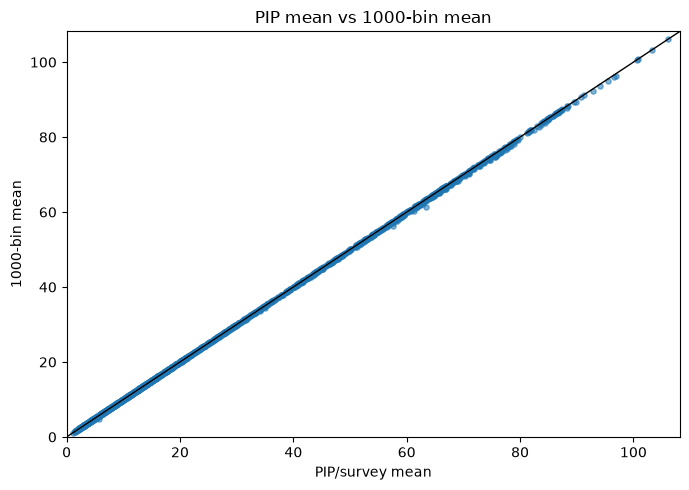

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(eda["mean"], eda["mean_1kbins"], s=14, alpha=0.55)
lims = [0, max(eda["mean"].max(), eda["mean_1kbins"].max()) * 1.02]
ax.plot(lims, lims, color="black", linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("PIP/survey mean")
ax.set_ylabel("1000-bin mean")
ax.set_title("PIP mean vs 1000-bin mean")
plt.tight_layout()

## 7. Trends by region, welfare type y survey

These cuts help see whether the problem is concentrated in certain survey types, regions, or welfare concepts.

Trends by region:

In [20]:
region_summary = (
    eda.groupby("region_name", observed=True)
    .agg(
        n=("country_code", "size"),
        countries=("country_code", "nunique"),
        mean_abs_pct=("abs_diff_mean_pct", "mean"),
        p95_abs_pct=("abs_diff_mean_pct", lambda x: x.quantile(0.95)),
        max_abs_pct=("abs_diff_mean_pct", "max"),
        problematic=("problematic", "sum"),
    )
    .sort_values("max_abs_pct", ascending=False)
)

region_summary

,n,countries,mean_abs_pct,p95_abs_pct,max_abs_pct,problematic
region_name,,,,,,
Sub-Saharan Africa,226,46,0.0021,0.0059,0.1499,7
Europe & Central Asia,1117,49,0.0013,0.0058,0.0341,7
Latin America & Caribbean,449,27,0.0011,0.0041,0.0199,3
"Middle East, North Africa, Afghanistan & Pakistan",134,17,0.0013,0.0064,0.0137,2
North America,68,2,0.0060,0.0106,0.0119,6
South Asia,33,6,0.0006,0.0013,0.0096,0
East Asia & Pacific,211,25,0.0014,0.0050,0.0086,0


Trends by welfare type: 

In [21]:
welfare_summary = (
    eda.groupby("welfare_type", observed=True)
    .agg(
        n=("country_code", "size"),
        mean_abs_pct=("abs_diff_mean_pct", "mean"),
        p95_abs_pct=("abs_diff_mean_pct", lambda x: x.quantile(0.95)),
        max_abs_pct=("abs_diff_mean_pct", "max"),
        problematic=("problematic", "sum"),
    )
    .sort_values("max_abs_pct", ascending=False)
)

welfare_summary

,n,mean_abs_pct,p95_abs_pct,max_abs_pct,problematic
welfare_type,,,,,
consumption,920,0.0009,0.0025,0.1499,7
income,1318,0.0019,0.0073,0.0341,18


Trends by country:

In [22]:
survey_summary = (
    eda.groupby(["country_code", "country_name", "survey_acronym"], observed=True)
    .agg(
        n=("year", "size"),
        first_year=("year", "min"),
        last_year=("year", "max"),
        max_abs_pct=("abs_diff_mean_pct", "max"),
        max_abs_diff=("abs_diff_mean", "max"),
        problematic=("problematic", "sum"),
    )
    .query("problematic > 0")
    .sort_values(["problematic", "max_abs_pct"], ascending=False)
)

survey_summary.head(30)

,,,n,first_year,last_year,max_abs_pct,max_abs_diff,problematic
country_code,country_name,survey_acronym,,,,,,
USA,United States,CPS-LIS,12,1990,2001,0.0119,0.8533,5
GBR,United Kingdom,FRS-LIS,28,1994,2021,0.0199,1.1462,4
BLZ,Belize,LFS,5,1993,1999,0.0199,0.2065,2
ISR,Israel,HES-LIS,24,1992,2022,0.0137,0.4666,2
MWI,Malawi,IHS-I,1,1997,1997,0.1499,0.8582,1
BEL,Belgium,PSBH-ECHP-LIS,2,1995,2000,0.0341,2.1616,1
MWI,Malawi,IHS-II,1,2004,2004,0.0259,0.0737,1
BEL,Belgium,EU-SILC,21,2003,2023,0.0168,1.0302,1
BWA,Botswana,HIES,2,1993,2002,0.0134,0.0987,1


In [23]:
survey_summary = (
    eda.groupby(["country_code", "country_name",], observed=True)
    .agg(
        n=("year", "size"),
        first_year=("year", "min"),
        last_year=("year", "max"),
        max_abs_pct=("abs_diff_mean_pct", "max"),
        max_abs_diff=("abs_diff_mean", "max"),
        problematic=("problematic", "sum"),
    )
    .query("problematic > 0")
    .sort_values(["problematic", "max_abs_pct"], ascending=False)
)

survey_summary.head(30)

,,n,first_year,last_year,max_abs_pct,max_abs_diff,problematic
country_code,country_name,,,,,,
USA,United States,35,1990,2024,0.0119,0.8533,6
GBR,United Kingdom,32,1990,2021,0.0199,1.1462,4
MWI,Malawi,5,1997,2019,0.1499,0.8582,3
BEL,Belgium,25,1992,2023,0.0341,2.1616,2
BLZ,Belize,8,1993,2018,0.0199,0.2065,2
ISR,Israel,24,1992,2022,0.0137,0.4666,2
BWA,Botswana,4,1993,2015,0.0134,0.0987,1
SYC,Seychelles,4,1999,2018,0.0122,0.3256,1
KEN,Kenya,8,1992,2022,0.0113,0.0949,1


## 8.Evolution for countries with problematic cases
The goal is to see whether the problem is persistent over time for each country (suggesting a structural issue with how that country's data is binned) or sporadic (appearing only in certain years, suggesting a data-specific event like a survey redesign or a particularly extreme observation in that year)

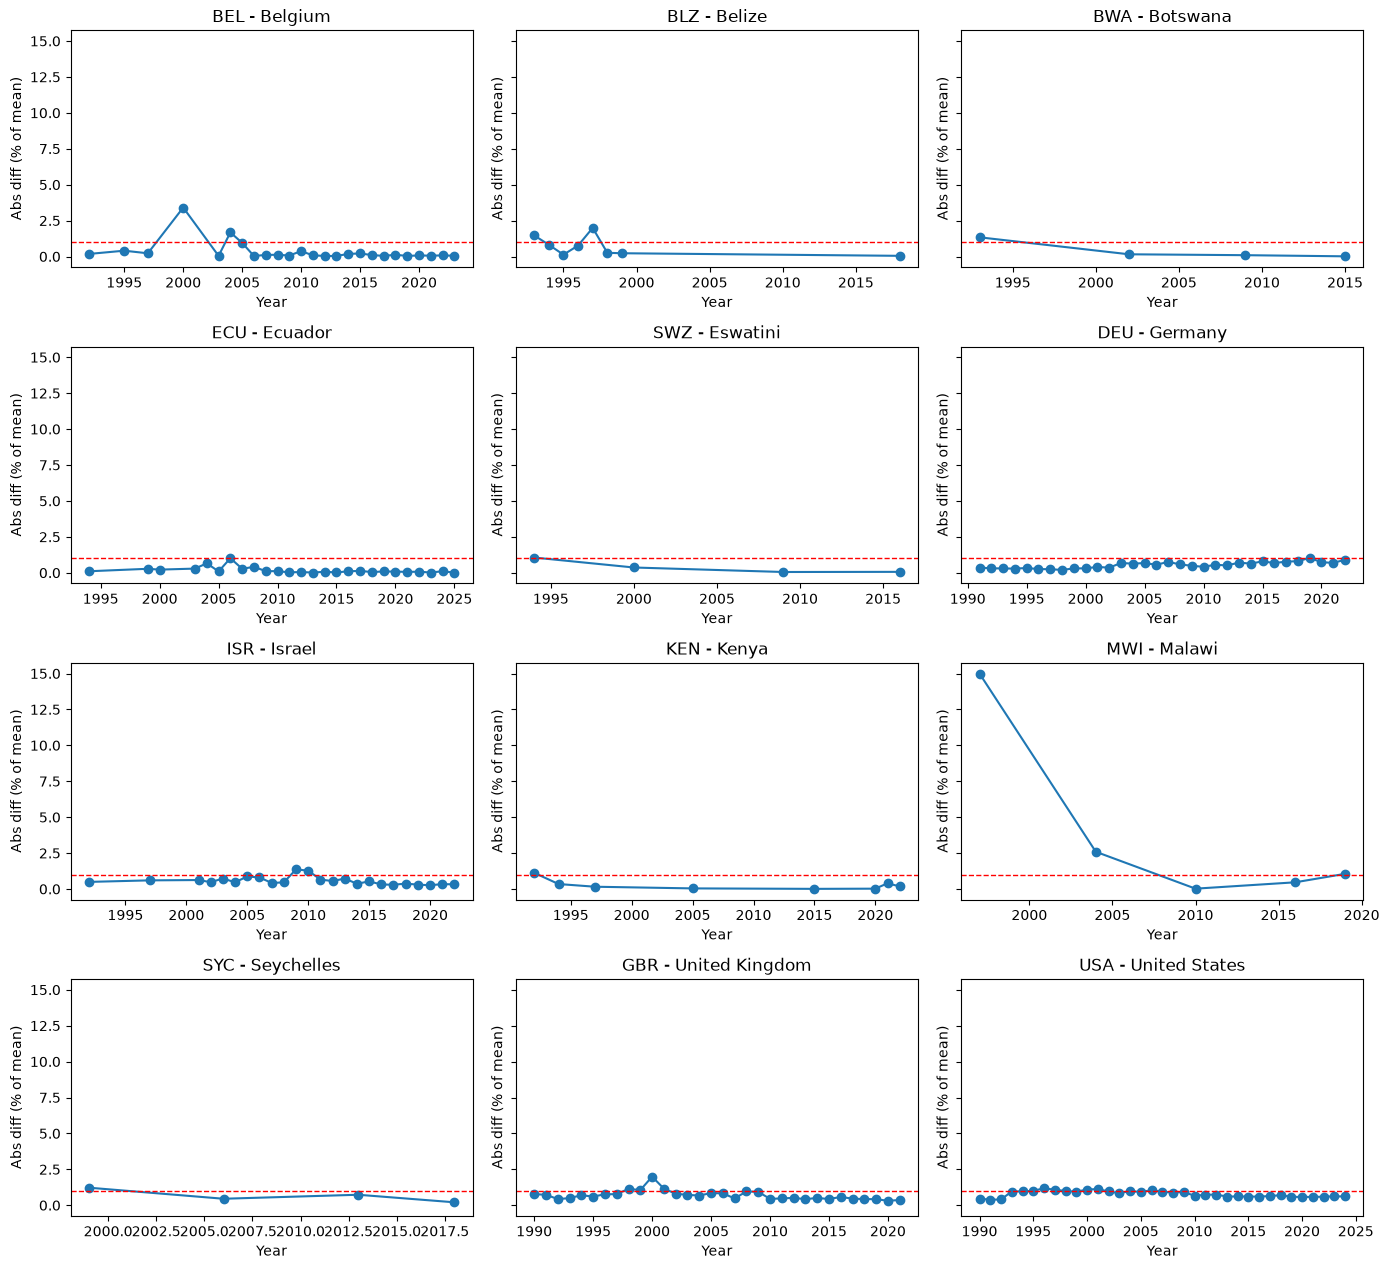

In [24]:
problem_countries = problematic["country_code"].unique().tolist()
plot_df = eda[eda["country_code"].isin(problem_countries)].copy()

n = len(problem_countries)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), sharey=True)
axes = np.array(axes).reshape(-1)

for ax, code in zip(axes, problem_countries):
    tmp = plot_df[plot_df["country_code"] == code].sort_values("year")
    ax.plot(tmp["year"], 100 * tmp["abs_diff_mean_pct"], marker="o", linewidth=1.5)
    ax.axhline(100 * REL_THRESHOLD, color="red", linewidth=1, linestyle="--")
    name = tmp["country_name"].iloc[0]
    ax.set_title(f"{code} - {name}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Abs diff (% of mean)")

for ax in axes[len(problem_countries):]:
    ax.axis("off")

plt.tight_layout()

## 9. Relationship with Inequality / Approximate Top Share

This does not establish causality, but it helps assess whether the gaps are larger when the reported distribution is more unequal.

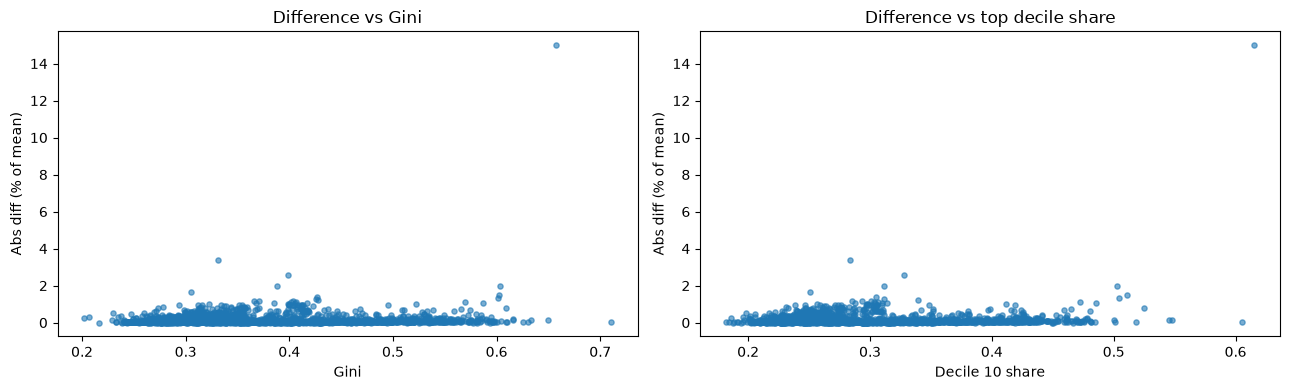

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(eda["gini"], 100 * eda["abs_diff_mean_pct"], s=14, alpha=0.6)
axes[0].set_xlabel("Gini")
axes[0].set_ylabel("Abs diff (% of mean)")
axes[0].set_title("Difference vs Gini")

axes[1].scatter(eda["decile10"], 100 * eda["abs_diff_mean_pct"], s=14, alpha=0.6)
axes[1].set_xlabel("Decile 10 share")
axes[1].set_ylabel("Abs diff (% of mean)")
axes[1].set_title("Difference vs top decile share")

plt.tight_layout()

In [26]:
eda[["abs_diff_mean_pct", "abs_diff_mean", "gini", "decile10", "mean"]].corr()

,abs_diff_mean_pct,abs_diff_mean,gini,decile10,mean
abs_diff_mean_pct,1.0000,0.5970,0.0909,0.1224,0.1819
abs_diff_mean,0.5970,1.0000,-0.0929,-0.1033,0.5539
gini,0.0909,-0.0929,1.0000,0.9818,-0.3817
decile10,0.1224,-0.1033,0.9818,1.0000,-0.4033
mean,0.1819,0.5539,-0.3817,-0.4033,1.0000


## 10. First double click: 1000 bin sensitivity

Load `problematic_topbin_sensitivity.csv`. This file asks: if the entire difference came exclusively from bin 1000, by how much would the average welfare in that bin have to change for mean_1kbins to equal mean?

In [27]:
sensitivity_path = OUT / "problematic_topbin_sensitivity.csv"

if sensitivity_path.exists():
    sens = pd.read_csv(sensitivity_path)
    display(sens.sort_values("diff_mean_pct", ascending=False).head(30))
else:
    print("No existe todavia:", sensitivity_path)
    print("Corre 00-code/02-problematic-top-tail.do para generarlo desde Stata.")

,country_code,country_name,year,welfare_type,survey_acronym,mean,mean_1kbins,diff_mean,diff_mean_pct,welf,pop_bin,topbin_share_of_1k_mean,topbin_mean_if_match_survey,topbin_pct_change_needed
0,MWI,Malawi,1997,consumption,IHS-I,5.7240,4.8658,0.8582,0.1499,"1,296.4863",0.0106,0.2664,"2,154.7034",0.6620
1,BEL,Belgium,2000,income,PSBH-ECHP-LIS,63.4297,61.2681,2.1616,0.0341,"2,526.3635",0.0103,0.0412,"4,687.9157",0.8556
2,MWI,Malawi,2004,consumption,IHS-II,2.8443,2.7706,0.0737,0.0259,55.9004,0.0125,0.0202,129.6070,1.3185
3,BLZ,Belize,1997,income,LFS,10.3573,10.1508,0.2065,0.0199,"1,646.7063",0.0002,0.1622,"1,853.1760",0.1254
4,GBR,United Kingdom,2000,income,FRS-LIS,57.5452,56.3991,1.1462,0.0199,"1,660.8053",0.0589,0.0294,"2,806.9764",0.6901
5,BEL,Belgium,2004,income,EU-SILC,61.3511,60.3209,1.0302,0.0168,"1,670.7194",0.0104,0.0277,"2,700.8759",0.6166
6,BLZ,Belize,1993,income,LFS,12.8201,12.6318,0.1882,0.0147,"1,542.4561",0.0002,0.1221,"1,730.6975",0.1220
7,ISR,Israel,2009,income,HES-LIS,34.1317,33.6651,0.4666,0.0137,642.1211,0.0075,0.0191,"1,108.7593",0.7267
8,BWA,Botswana,1993,consumption,HIES,7.3858,7.2871,0.0987,0.0134,656.1374,0.0014,0.0900,754.8740,0.1505
9,ISR,Israel,2010,income,HES-LIS,34.9375,34.4915,0.4459,0.0128,629.5397,0.0076,0.0183,"1,075.4766",0.7084


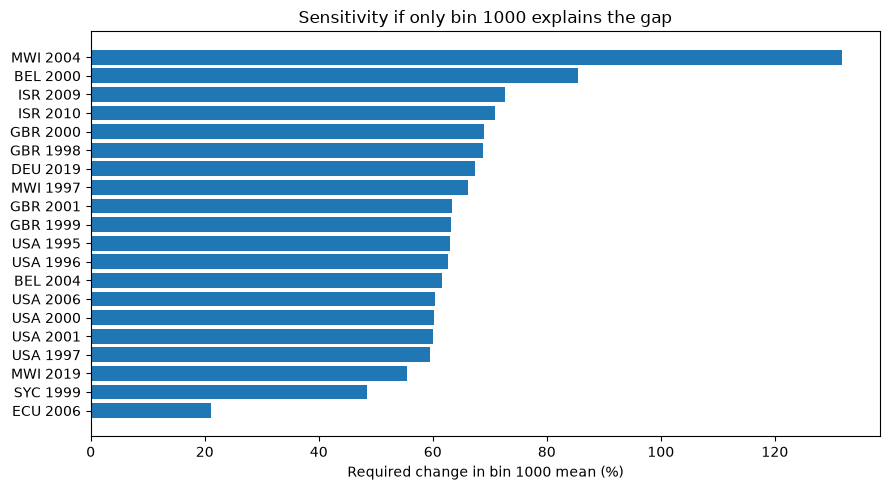

In [28]:
if sensitivity_path.exists():
    fig, ax = plt.subplots(figsize=(9, 5))
    tmp = sens.sort_values("topbin_pct_change_needed", ascending=False).head(20).copy()
    labels = tmp["country_code"] + " " + tmp["year"].astype(int).astype(str)
    ax.barh(labels[::-1], 100 * tmp["topbin_pct_change_needed"][::-1])
    ax.set_xlabel("Required change in bin 1000 mean (%)")
    ax.set_title("Sensitivity if only bin 1000 explains the gap")
    plt.tight_layout()

# Extra / dont consider

In [29]:
df_malawi_1997 = pd.read_stata(MWI_1997_path)

df_malawi_1997.shape, df_malawi_1997.columns.tolist()
df_malawi_1997

,countrycode,hhid,welfare,urban,hsize,wta_hh,weight,fdpindex,nfdpindex,pc_hhdr,subnatid,code,year,survname,cpi_domain,cpi_domain_value,cpi2021_unadj,cpi2017_unadj,cpi2011_unadj,cpi2011,cpi2017,cpi2021,icp2011,icp2017,icp2021,comparability,cpi_replication,cpi_domain_var,icpreplication,icpdomain_var,icpdomain_value,comparable,cpi2005,icp2005,cpi_data_level,cpi2011_SM26,cpi2017_SM26,cpi2021_SM26,icp2011_SM26,icp2017_SM26,icp2021_SM26
0,MWI,"10,177,002,005.0000","7,068.1660",Rural,1,187.2218,187.2218,0.7410,0.7410,"9,538.6855",301 – Nsanje,MWI,"1,997.0000",IHS-I,National,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
1,MWI,"10,177,002,008.0000","9,334.1377",Rural,2,187.2218,374.4435,0.7410,0.7410,"12,596.6768",301 – Nsanje,MWI,"1,997.0000",IHS-I,National,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
2,MWI,"10,177,002,009.0000","6,705.0552",Rural,4,187.2218,748.8870,0.7410,0.7410,"9,048.6572",301 – Nsanje,MWI,"1,997.0000",IHS-I,National,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
3,MWI,"10,177,002,023.0000","3,693.1663",Rural,7,187.2218,"1,310.5522",0.7410,0.7410,"4,984.0303",301 – Nsanje,MWI,"1,997.0000",IHS-I,National,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
4,MWI,"10,177,002,025.0000","5,462.6602",Rural,2,187.2218,374.4435,0.7410,0.7410,"7,372.0107",301 – Nsanje,MWI,"1,997.0000",IHS-I,National,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10693,MWI,"353,501,039,095.0000","6,549.4707",Rural,5,114.0455,570.2273,1.1240,1.1240,"5,826.9316",135 – Chitipa,MWI,"1,997.0000",IHS-I,National,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
10694,MWI,"353,501,039,108.0000","4,532.8530",Rural,7,114.0455,798.3182,1.1240,1.1240,"4,032.7876",135 – Chitipa,MWI,"1,997.0000",IHS-I,National,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
10695,MWI,"353,501,039,117.0000","16,584.1094",Rural,1,114.0455,114.0455,1.1240,1.1240,"14,754.5469",135 – Chitipa,MWI,"1,997.0000",IHS-I,National,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
10696,MWI,"353,501,039,123.0000","13,787.3555",Rural,2,114.0455,228.0909,1.1240,1.1240,"12,266.3311",135 – Chitipa,MWI,"1,997.0000",IHS-I,National,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942


In [30]:
pip_1000_bins = pd.read_stata(pip_1000_bins_path)

pip_1000_bins.shape, pip_1000_bins.columns.tolist()
pip_1000_bins



,year,code,region_name,region_code,regionpcn_name,regionpcn_code,quantile,welf,pop,pipvintage
0,"1,990.0000",ABW,Latin America & Caribbean,LCN,Other High Income Countries,OHI,1.0000,0.4798,0.0001,20260324_2021_01_02_PROD
1,"1,990.0000",ABW,Latin America & Caribbean,LCN,Other High Income Countries,OHI,2.0000,0.8469,0.0001,20260324_2021_01_02_PROD
2,"1,990.0000",ABW,Latin America & Caribbean,LCN,Other High Income Countries,OHI,3.0000,1.0942,0.0001,20260324_2021_01_02_PROD
3,"1,990.0000",ABW,Latin America & Caribbean,LCN,Other High Income Countries,OHI,4.0000,1.2940,0.0001,20260324_2021_01_02_PROD
4,"1,990.0000",ABW,Latin America & Caribbean,LCN,Other High Income Countries,OHI,5.0000,1.4665,0.0001,20260324_2021_01_02_PROD
...,...,...,...,...,...,...,...,...,...,...
8064995,"2,026.0000",ZWE,Sub-Saharan Africa,SSF,Sub-Saharan Africa,SSA,996.0000,51.3816,0.0173,20260324_2021_01_02_PROD
8064996,"2,026.0000",ZWE,Sub-Saharan Africa,SSF,Sub-Saharan Africa,SSA,997.0000,57.0318,0.0173,20260324_2021_01_02_PROD
8064997,"2,026.0000",ZWE,Sub-Saharan Africa,SSF,Sub-Saharan Africa,SSA,998.0000,67.4127,0.0173,20260324_2021_01_02_PROD
8064998,"2,026.0000",ZWE,Sub-Saharan Africa,SSF,Sub-Saharan Africa,SSA,999.0000,94.2638,0.0173,20260324_2021_01_02_PROD


Ideas for next steps:
1. Investigate how bins are created
2. Replicate Malawi 1997 to rest of cases and see if there is a trend
